# Von der MP3 zum IQ-Signal am Antennenarray

Dieses Notebook zeigt Schritt fuer Schritt, wie aus einer normalen Musikdatei
das komplexe Basisband-Signal (IQ) entsteht, das ein UKW-Sender abstrahlt, und
wie dieses Signal an einem kreisfoermigen Antennenarray (UCA) ankommt.

**Die Kette im Ueberblick:**

1. **MP3 laden** -> Stereo links/rechts (L, R)
2. **Resampling** auf die Basisband-Abtastrate `fs`
3. **Stereo-Multiplex (MPX)** bauen: Mono + Pilot (19 kHz) + Differenz auf 38 kHz
4. **FM-Modulation** -> komplexes Basisband `s(t) = exp(j*phi(t))` (das IQ-Signal)
5. **Array-Geometrie & Steering-Vektor** des UCA
6. **Empfang**: jede Antenne bekommt `x_n(t) = a_n * s(t)`

Ziel ist am Ende ein Array `X` der Form `(N_Antennen, N_Samples)` mit komplexen
Werten - genau das, was `stream.py` blockweise erzeugt.

> Jede Zelle ist bewusst *von Hand* ausgeschrieben (nicht nur `import`), damit du
> jeden Schritt nachvollziehen und selbst nachbauen kannst. In Klammern steht
> jeweils, in welchem Modul der Code spaeter 'echt' liegt.

## 0. Setup

Wir importieren die Bibliotheken und setzen die zentralen Parameter. `fs` ist die
wichtigste Zahl: die Abtastrate des Basisbands. Sie muss hoch genug sein, um den
gesamten MPX (bis ~57 kHz) und die FM-Bandbreite abzubilden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from fractions import Fraction
from scipy.signal import resample_poly

# --- zentrale Parameter ---
AUDIO_PATH  = 'audio_music.mp3'
FS_HZ       = 240_000.0     # Basisband-Abtastrate [Hz]
DURATION_S  = 0.3           # nur ein kurzer Ausschnitt, damit das Notebook flott bleibt

PILOT_HZ     = 19_000.0     # Stereo-Pilotton
DEVIATION_HZ = 75_000.0     # max. Frequenzhub der FM (UKW-Norm)
AUDIO_CUTOFF_HZ = 15_000.0  # Audio-Bandbreite je Kanal

FC_HZ = 89.5e6              # Sendefrequenz (nur fuer Geometrie/Steering relevant)
C_LIGHT = 299_792_458.0

plt.rcParams['figure.figsize'] = (9, 3)
print('Setup ok s')

Setup ok s


## 1. MP3 laden  (entspricht `audio.load_audio`)

`soundfile.read` liefert die Samples als Array `(Anzahl, Kanaele)` sowie die
originale Abtastrate der Datei (`fs_file`, bei MP3 meist 44100 Hz).
Wir trennen den linken und rechten Kanal. Ist die Datei mono, kopieren wir den
einen Kanal auf beide Seiten.

In [2]:
data, fs_file = sf.read(AUDIO_PATH, dtype='float64', always_2d=True)
print('Roh-Shape:', data.shape, '  Datei-Abtastrate:', fs_file, 'Hz')

left_raw  = data[:, 0]
right_raw = data[:, 1] if data.shape[1] >= 2 else data[:, 0]
print('Dauer der Datei:', round(len(left_raw)/fs_file, 2), 's')

Roh-Shape: (1513728, 2)   Datei-Abtastrate: 44100 Hz
Dauer der Datei: 34.32 s


Ein kurzer Blick auf die Wellenform (erste 20 ms). Man sieht die reine
Audio-Schwingung - noch nichts Radar-spezifisches.

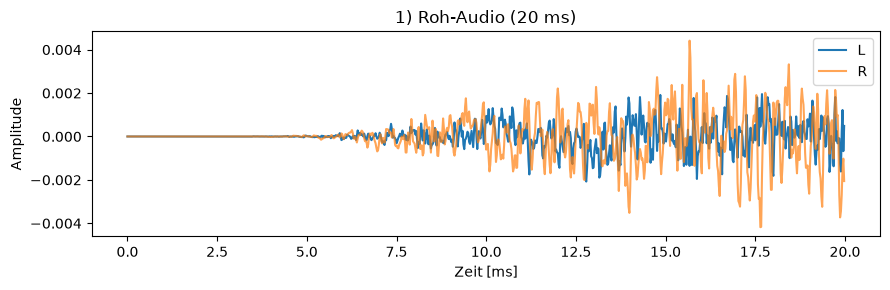

In [3]:
n_show = int(0.02 * fs_file)   # 20 ms
t_ms = np.arange(n_show) / fs_file * 1e3
plt.plot(t_ms, left_raw[:n_show], label='L')
plt.plot(t_ms, right_raw[:n_show], label='R', alpha=0.7)
plt.xlabel('Zeit [ms]'); plt.ylabel('Amplitude'); plt.title('1) Roh-Audio (20 ms)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Resampling + Normalisierung  (entspricht `audio._resample` / `_normalize`)

Das Audio kommt mit 44100 Hz, unser Basisband laeuft mit `fs = 240000 Hz`. Wir
muessen also **umtasten (resampling)**. `resample_poly` macht das ueber ein exaktes
rationales Verhaeltnis `p/q` und filtert dabei gegen Aliasing.

$$ \frac{p}{q} = \frac{f_{out}}{f_{in}} = \frac{240000}{44100} = \frac{800}{147} $$

Danach kuerzen wir auf `DURATION_S` und **normalisieren** beide Kanaele gemeinsam
auf Spitzenwert 1 (gemeinsam, damit das Stereobild L-R nicht verzerrt wird).

In [4]:
def resample(x, fs_in, fs_out):
    if int(fs_in) == int(fs_out):
        return np.asarray(x, dtype=np.float64)
    ratio = Fraction(int(fs_out), int(fs_in))
    return resample_poly(x, ratio.numerator, ratio.denominator)

left  = resample(left_raw,  fs_file, FS_HZ)
right = resample(right_raw, fs_file, FS_HZ)

# auf gewuenschte Laenge kuerzen
m = int(round(DURATION_S * FS_HZ))
left, right = left[:m], right[:m]

# gemeinsame Normalisierung
peak = max(np.max(np.abs(left)), np.max(np.abs(right)))
left, right = left / peak, right / peak

print('Ratio p/q =', Fraction(int(FS_HZ), int(fs_file)))
print('Samples nach Resampling:', left.shape, '  =', round(len(left)/FS_HZ,3), 's @', FS_HZ, 'Hz')
print('Wertebereich L: [%.3f, %.3f]' % (left.min(), left.max()))

Ratio p/q = 800/147
Samples nach Resampling: (72000,)   = 0.3 s @ 240000.0 Hz
Wertebereich L: [-0.992, 0.986]


Zur Kontrolle das **Amplitudenspektrum** des Audios. Musik hat ihren Inhalt vor
allem unter ~15 kHz - genau die Bandbreite, die ein UKW-Sender uebertraegt.
Wir bauen uns eine kleine Hilfsfunktion fuer Spektren, die wir spaeter wieder nutzen.

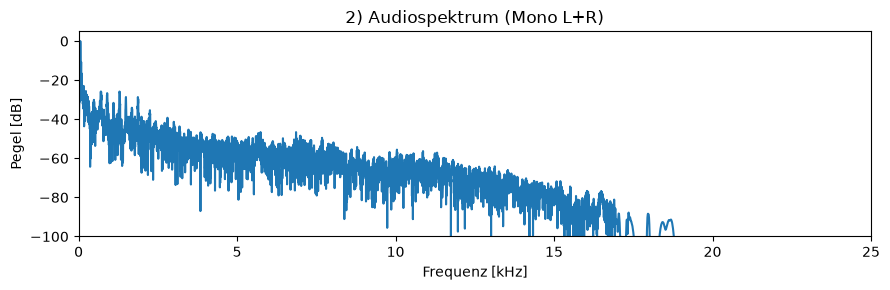

In [5]:
def plot_spectrum(x, fs, fmax=None, title=''):
    X = np.fft.rfft(x * np.hanning(len(x)))
    f = np.fft.rfftfreq(len(x), 1.0/fs)
    mag_db = 20*np.log10(np.abs(X) + 1e-12)
    mag_db -= mag_db.max()          # 0 dB = Maximum
    plt.plot(f/1e3, mag_db)
    if fmax: plt.xlim(0, fmax/1e3)
    plt.ylim(-100, 5)
    plt.xlabel('Frequenz [kHz]'); plt.ylabel('Pegel [dB]'); plt.title(title)

plot_spectrum(0.5*(left+right), FS_HZ, fmax=25e3, title='2) Audiospektrum (Mono L+R)')
plt.tight_layout(); plt.show()

## 3. Stereo-Multiplex (MPX)  (entspricht `transmitter.FMStream._multiplex`)

Bevor moduliert wird, packt der Sender L und R in ein einziges Basisband-Signal,
das **MPX-Signal**. Es besteht aus drei Teilen:

| Anteil | Frequenzlage | Formel |
|---|---|---|
| **Mono** (L+R) | 0 - 15 kHz | $\tfrac12(L+R)$ |
| **Pilot** | 19 kHz | $0.1\,\sin(2\pi f_p t)$ |
| **Differenz** (L-R) | 38 kHz (DSB) | $\tfrac12(L-R)\,\sin(4\pi f_p t)$ |

Der Pilot bei 19 kHz sagt dem Empfaenger, wo der 38-kHz-Traeger (= 2x Pilot) liegt,
um den die Differenz als Zweiseitenband (DSB) moduliert ist. So bleibt das Signal
abwaertskompatibel zu Mono-Empfaengern.

In [6]:
t = np.arange(len(left)) / FS_HZ

mono = 0.5 * (left + right)                       # 0..15 kHz
diff = 0.5 * (left - right)
subcarrier = np.sin(4.0 * np.pi * PILOT_HZ * t)   # 38 kHz Traeger
pilot      = np.sin(2.0 * np.pi * PILOT_HZ * t)   # 19 kHz

mpx = 0.9 * (mono + diff * subcarrier) + 0.1 * pilot
print('MPX shape:', mpx.shape, '  Wertebereich: [%.3f, %.3f]' % (mpx.min(), mpx.max()))

MPX shape: (72000,)   Wertebereich: [-0.974, 0.978]


Jetzt sieht man im Spektrum die drei Bausteine klar getrennt: den Mono-Block
(0-15 kHz), den scharfen **Pilot bei 19 kHz** und das **Differenzband um 38 kHz**.
Genau deshalb muss `fs` gross sein (240 kHz reicht locker fuer 57 kHz Inhalt).

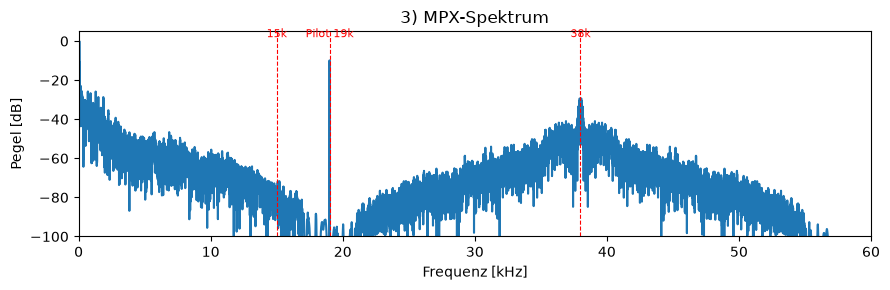

In [7]:
plot_spectrum(mpx, FS_HZ, fmax=60e3, title='3) MPX-Spektrum')
for fx, name in [(15,'15k'), (19,'Pilot 19k'), (38,'38k')]:
    plt.axvline(fx, color='r', ls='--', lw=0.8)
    plt.text(fx, 2, name, color='r', fontsize=8, ha='center')
plt.tight_layout(); plt.show()

## 4. FM-Modulation -> das IQ-Signal  (entspricht `FMStream.next_block`)

Jetzt der Kern. Bei **Frequenzmodulation** steckt die Information in der
*Momentanfrequenz*: sie weicht proportional zum MPX vom Traeger ab.

$$ f_{\text{mom}}(t) = \Delta f \cdot m(t) \qquad (\Delta f = 75\,\text{kHz}) $$

Die **Phase** ist das Integral der Frequenz (hier als kumulative Summe):

$$ \varphi(t) = 2\pi \int_0^t f_{\text{mom}}(\tau)\,d\tau
   \;\approx\; \frac{2\pi}{f_s}\sum_{k=0}^{n} f_{\text{mom}}[k] $$

Das gesendete **komplexe Basisband** (IQ-Signal) ist dann:

$$ s(t) = e^{\,j\varphi(t)} = \underbrace{\cos\varphi(t)}_{I} + j\underbrace{\sin\varphi(t)}_{Q} $$

`s` hat konstanten Betrag 1 - typisch fuer FM. Die ganze Information sitzt im
*Winkel*, nicht in der Amplitude.

In [8]:
inst_freq = DEVIATION_HZ * mpx                       # Momentanfrequenz [Hz]
phase = 2.0 * np.pi * np.cumsum(inst_freq) / FS_HZ   # Phase [rad]
s = np.exp(1j * phase)                               # komplexes Basisband (IQ)

print('s dtype:', s.dtype, '  shape:', s.shape)
print('Betrag |s| konstant? min=%.3f max=%.3f' % (np.abs(s).min(), np.abs(s).max()))

s dtype: complex128   shape: (72000,)
Betrag |s| konstant? min=1.000 max=1.000


### 4a. I und Q im Zeitbereich
Real- (I) und Imaginaerteil (Q) sind zwei um 90 Grad versetzte Schwingungen,
deren *Frequenz* sich staendig aendert.

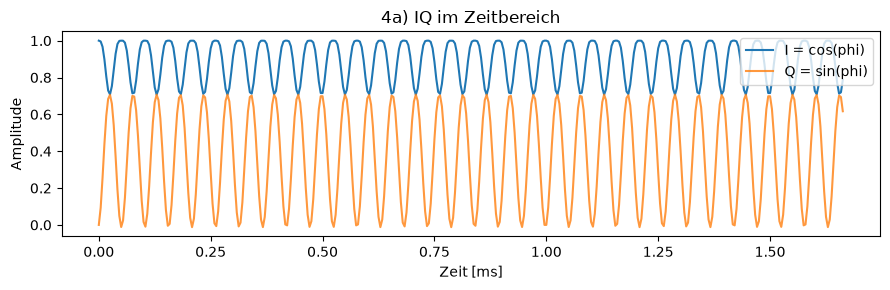

In [9]:
n_show = 400
plt.plot(t[:n_show]*1e3, s.real[:n_show], label='I = cos(phi)')
plt.plot(t[:n_show]*1e3, s.imag[:n_show], label='Q = sin(phi)', alpha=0.8)
plt.xlabel('Zeit [ms]'); plt.ylabel('Amplitude'); plt.title('4a) IQ im Zeitbereich')
plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

### 4b. Konstellation (I vs. Q)
Traegt man Q ueber I auf, liegen alle Punkte auf dem **Einheitskreis** - der
visuelle Beweis fuer den konstanten Betrag. Die Information ist die
Winkelgeschwindigkeit, mit der sich der Punkt auf dem Kreis bewegt.

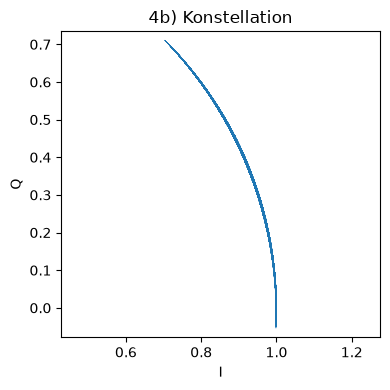

In [10]:
plt.figure(figsize=(4,4))
plt.plot(s.real[:2000], s.imag[:2000], lw=0.4)
plt.xlabel('I'); plt.ylabel('Q'); plt.title('4b) Konstellation'); plt.axis('equal')
plt.tight_layout(); plt.show()

### 4c. Momentanfrequenz vs. Audio
Die Momentanfrequenz folgt exakt dem MPX-Verlauf (bis auf den Faktor `Delta f`).
Man kann sie auch aus `s` zurueckgewinnen - genau das macht ein FM-Demodulator:
`f = fs/(2*pi) * d/dt arg(s)`.

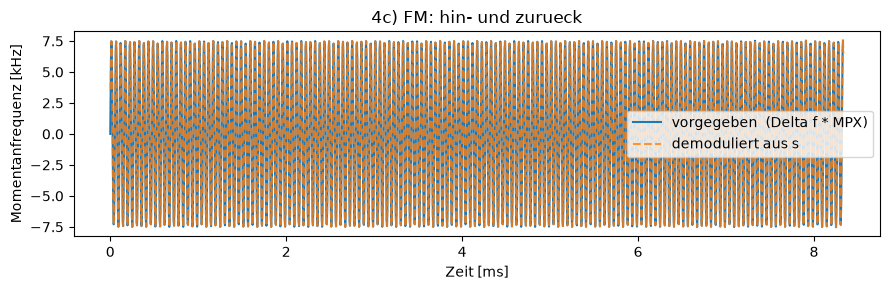

In [11]:
# Demodulation zur Kontrolle: Ableitung der entwickelten Phase
phase_unwrapped = np.unwrap(np.angle(s))
f_demod = np.diff(phase_unwrapped) * FS_HZ / (2*np.pi)

n_show = 2000
plt.plot(t[:n_show]*1e3, inst_freq[:n_show]/1e3, label='vorgegeben  (Delta f * MPX)')
plt.plot(t[1:n_show+1]*1e3, f_demod[:n_show]/1e3, '--', label='demoduliert aus s', alpha=0.8)
plt.xlabel('Zeit [ms]'); plt.ylabel('Momentanfrequenz [kHz]')
plt.title('4c) FM: hin- und zurueck'); plt.legend(); plt.tight_layout(); plt.show()

### 4d. Spektrum des FM-Signals & Carson-Bandbreite
Durch die FM verschmiert das schmale Audio auf eine breite Bandbreite. Die
Faustformel dafuer ist die **Carson-Bandbreite**:

$$ B \approx 2\,(\Delta f + f_{max}) $$

mit `f_max = 2*Pilot + 15 kHz = 53 kHz`. Da `s` komplex ist, ist das Spektrum
nicht symmetrisch um 0 - deshalb zeigen wir positive und negative Frequenzen.

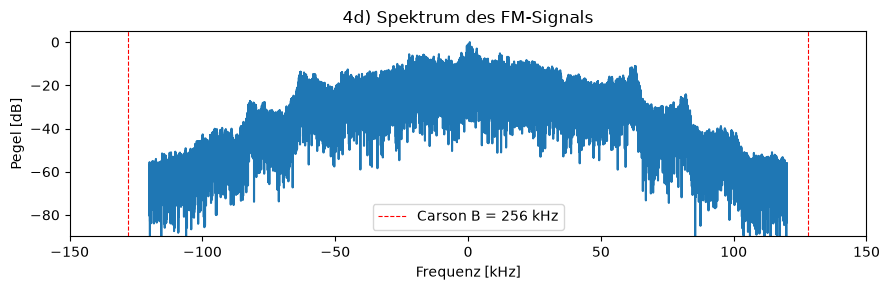

In [12]:
S = np.fft.fftshift(np.fft.fft(s * np.hanning(len(s))))
f = np.fft.fftshift(np.fft.fftfreq(len(s), 1.0/FS_HZ))
mag = 20*np.log10(np.abs(S)+1e-12); mag -= mag.max()
plt.plot(f/1e3, mag)

f_max = 2*PILOT_HZ + AUDIO_CUTOFF_HZ
B = 2*(DEVIATION_HZ + f_max)
plt.axvline(-B/2/1e3, color='r', ls='--', lw=0.8)
plt.axvline( B/2/1e3, color='r', ls='--', lw=0.8, label='Carson B = %.0f kHz' % (B/1e3))
plt.xlim(-150,150); plt.ylim(-90,5)
plt.xlabel('Frequenz [kHz]'); plt.ylabel('Pegel [dB]')
plt.title('4d) Spektrum des FM-Signals'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Array-Geometrie & Steering-Vektor  (entspricht `uca.py`)

Bis hier haben wir *ein* Signal `s(t)`. Ein Passivradar-Empfaenger hat aber mehrere
Antennen. Wir nutzen ein **Uniform Circular Array (UCA)**: `N` Antennen
gleichmaessig auf einem Kreis mit Radius `r`.

Eine ebene Welle aus Richtung `phi_tx` (Azimut zum Sender) erreicht die Antennen zu
leicht **unterschiedlichen Zeiten** -> das aeussert sich als **Phasenverschiebung**:

$$ \alpha_n = \frac{2\pi}{\lambda}\, r \cos(\phi_n - \phi_{tx}),
   \qquad \phi_n = \frac{2\pi n}{N} $$

Der **Steering-Vektor** sammelt diese Phasen: `a_n = exp(j*alpha_n)`.

In [13]:
N = 7
D_OVER_LAMBDA = 0.4
TX_POS = (5_000.0, 3_000.0)   # Senderposition [m]
RX_POS = (0.0, 0.0)           # Array im Ursprung

lam = C_LIGHT / FC_HZ
d = D_OVER_LAMBDA * lam                       # Elementabstand
r = d / (2.0 * np.sin(np.pi / N))             # Radius aus gewuenschtem Abstand

phi_elem = 2.0 * np.pi * np.arange(N) / N     # Winkel der Elemente
pos = np.stack([r*np.cos(phi_elem), r*np.sin(phi_elem)], axis=1)

phi_tx = np.arctan2(TX_POS[1]-RX_POS[1], TX_POS[0]-RX_POS[0])   # Azimut zum Sender
alpha = (2*np.pi/lam) * r * np.cos(phi_elem - phi_tx)
a = np.exp(1j*alpha)                          # Steering-Vektor

print('lambda = %.3f m,  Radius r = %.3f m' % (lam, r))
print('Azimut zum Sender: %.1f Grad' % np.degrees(phi_tx))
print('Steering-Vektor a:', np.round(a, 2))

lambda = 3.350 m,  Radius r = 1.544 m
Azimut zum Sender: 31.0 Grad
Steering-Vektor a: [-0.79+0.61j -0.91+0.42j  0.62+0.78j -0.02-1.j   -0.97-0.25j -0.42-0.91j
  0.93+0.37j]


Links die Array-Geometrie mit Blickrichtung zum Sender, rechts die Phase jedes
Elements. Elemente, die der Welle 'entgegenstehen', haben eine andere Phase als die
auf der abgewandten Seite.

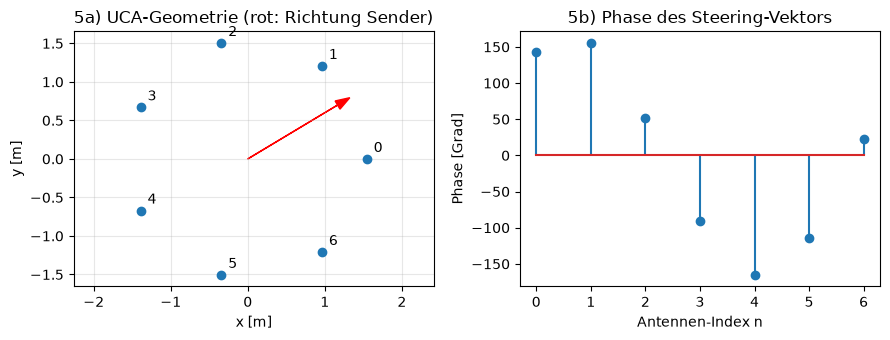

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))

ax[0].scatter(pos[:,0], pos[:,1], c='tab:blue', zorder=3)
for i,(x,y) in enumerate(pos):
    ax[0].annotate(str(i), (x,y), textcoords='offset points', xytext=(5,5))
ax[0].arrow(0,0, np.cos(phi_tx)*r, np.sin(phi_tx)*r, color='r',
            head_width=r*0.08, length_includes_head=True)
ax[0].set_title('5a) UCA-Geometrie (rot: Richtung Sender)')
ax[0].set_xlabel('x [m]'); ax[0].set_ylabel('y [m]'); ax[0].axis('equal'); ax[0].grid(alpha=0.3)

ax[1].stem(np.arange(N), np.degrees(np.angle(a)))
ax[1].set_title('5b) Phase des Steering-Vektors')
ax[1].set_xlabel('Antennen-Index n'); ax[1].set_ylabel('Phase [Grad]')
plt.tight_layout(); plt.show()

## 6. Empfang am Array  (entspricht `receiver.receive_array`)

Im Schmalband-Modell bekommt jede Antenne dasselbe Signal `s(t)`, nur mit ihrer
eigenen Phase multipliziert:

$$ x_n(t) = a_n \cdot s(t) $$

Das ergibt eine Matrix `X` der Form `(N, Samples)` - **das ist das Zielprodukt**.
Per Broadcasting in einer Zeile:

In [15]:
X = (a[:, None] * s[None, :]).astype(np.complex64)
print('X shape:', X.shape, ' dtype:', X.dtype, '  -> (Antennen, Samples)')

X shape: (7, 72000)  dtype: complex64   -> (Antennen, Samples)


Zwei Kontrollen:
- **Betrag** ist auf allen Antennen gleich (nur die Phase unterscheidet sich).
- Die **Phasendifferenz** zweier Antennen ist konstant = Differenz ihrer
  Steering-Phasen. Genau diese Differenzen wertet ein Peiler/Beamformer spaeter aus.

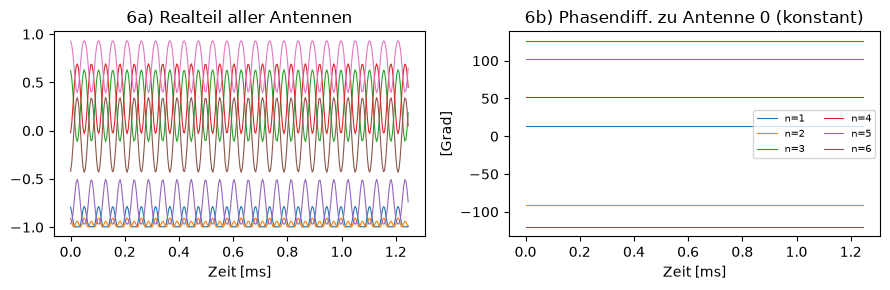

Betrag pro Antenne (sollte identisch sein): [1. 1. 1. 1. 1. 1. 1.]


In [16]:
n_show = 300
fig, ax = plt.subplots(1, 2, figsize=(9,3))

for n in range(N):
    ax[0].plot(t[:n_show]*1e3, X[n].real[:n_show], lw=0.8)
ax[0].set_title('6a) Realteil aller Antennen'); ax[0].set_xlabel('Zeit [ms]')

# Phasendifferenz Antenne n gegen Antenne 0
dphase = np.degrees(np.angle(X[:, :n_show] * np.conj(X[0, :n_show])))
for n in range(1, N):
    ax[1].plot(t[:n_show]*1e3, dphase[n], lw=0.8, label='n=%d'%n)
ax[1].set_title('6b) Phasendiff. zu Antenne 0 (konstant)')
ax[1].set_xlabel('Zeit [ms]'); ax[1].set_ylabel('[Grad]'); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

print('Betrag pro Antenne (sollte identisch sein):', np.round(np.abs(X).mean(axis=1), 3))

## 7. Zusammenfassung

Die komplette Kette in Kurzform:

```
MP3  --sf.read-->  L, R
     --resample_poly-->  L, R @ fs
     --0.5(L+R) + 0.1*pilot + 0.5(L-R)*sin(2*w_p t)-->  MPX
     --exp(j * 2pi/fs * cumsum(deltaf * MPX))-->  s(t)   (IQ, |s|=1)
     --a_n * s(t)-->  X  mit Form (N, Samples)
```

**Die Module machen genau das:**
- `audio.py`      -> Schritt 1-2 (`load_audio`)
- `transmitter.py`-> Schritt 3-4 (`FMStream`)
- `uca.py`        -> Schritt 5 (`steering_vector` & Geometrie)
- `receiver.py`   -> Schritt 6 (`receive_array`)
- `stream.py`     -> setzt alles zusammen und liefert es **blockweise** (Generator),
  damit man einen kontinuierlichen Datenstrom fuer die Radarverarbeitung hat.

Der einzige Unterschied zum 'echten' Code: `FMStream.next_block` merkt sich die
**Restphase** zwischen den Bloecken, damit an den Blockgrenzen kein Phasensprung
entsteht. Sonst ist es identisch zu dem, was du hier von Hand gebaut hast.